# 🌀 MetroPT3 Air Compressor Anomaly Detection
## Unsupervised & Semi-Supervised Anomaly Detection in Railway Transit Subsystems

### Project Context & Mechanical Background
This repository develops an advanced predictive maintenance (PdM) and anomaly detection pipeline for a critical rolling stock subsystem: the **Metro Train Air Compressor (PT3 Dataset)**. In railway transit, the compressor is the heart of the pneumatic system, directly supplying the compressed air required for mechanical braking systems and automated passenger doors. A failure here leads to immediate service disruptions and severe safety risks.

The dataset consists of high-frequency telemetry captured from multiple physical sensors over several months, monitoring parameters such as Pressure (TP2, TP3, H1), Motor Current, Air Intake Temperature (DV_electric), and Flow Rates (Air_Consum_v2).

Because catastrophic compressor failures are rare operational events, this pipeline treats fault monitoring as an Unsupervised/Semi-Supervised Anomaly Detection task. By training boundary-estimation models (**Isolation Forest** and **One-Class SVM**) exclusively on stabilized, healthy compressor behaviors, the system learns to isolate subtle statistical deviations and degradations before they evolve into functional failures.

In [1]:
# ============================================================================
# 1.A Standard Scientific Computing & Data Visualization Libraries
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1.B Machine Learning Frameworks (Scikit-Learn)
# ============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
# Load the raw telemetry dataset
df = pd.read_csv('/kaggle/input/datasets/anshtanwar/metro-train-dataset/MetroPT3(AirCompressor).csv')
df.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 💾 Data Ingestion & Chronological Indexing

### Engineering Rationale
Industrial telemetry data from rolling stock components is inherently sequential. To maintain physical and temporal continuity, we drop any artifact formatting columns (such as `Unnamed: 0`), cast the absolute log dates into formal `datetime64` structures, and enforce a chronological sorting of the index. This establishes a strict time-series alignment, which is vital for calculating rolling statistical windows and tracking degradation over months of metro operations.

In [3]:
# ============================================================================
# 2. Data Cleaning and Time-Series Indexing Pipeline
# ============================================================================
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert timestamp to datetime and set as chronological index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)
df.head()

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 📊 Exploratory Data Analysis (EDA) - Digital Sensor Diagnostics

### Engineering Rationale
The compressor subsystem monitors its state through a mix of analog parameters and binary/digital switches (`digital_cols`). These binary control indicators track discrete states such as the compressor activation status (`COMP`), electrical solenoid valves (`DV_electric`), and critical low-pressure safety cutouts (`LPS`).

By calculating the frequency distribution of these discrete states via value counts, we establish a behavioral baseline. This allows us to verify state distributions, detect severe operational class imbalances, and ensure that our digital indicators have not experienced electrical signaling dropouts or sensor locking before feeding them into our outlier-detection algorithms.

In [4]:
# ============================================================================
# 3. Discrete State & Digital Sensor Distribution Analysis
# ============================================================================
# Define the full matrix of discrete/binary operational control indicators
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

print('--- Exploring State Distributions for Digital Control Sensors ---')
for col in digital_cols:
    print(f"Feature: [{col}] | Unique Discrete Values & Frequency Percentages:")
    print(df[col].value_counts(normalize=False))  # Displays raw counts
    print("-" * 50)

--- Exploring State Distributions for Digital Control Sensors ---
Feature: [COMP] | Unique Discrete Values & Frequency Percentages:
COMP
1.0    1269620
0.0     247328
Name: count, dtype: int64
--------------------------------------------------
Feature: [DV_eletric] | Unique Discrete Values & Frequency Percentages:
DV_eletric
0.0    1273310
1.0     243638
Name: count, dtype: int64
--------------------------------------------------
Feature: [Towers] | Unique Discrete Values & Frequency Percentages:
Towers
1.0    1395362
0.0     121586
Name: count, dtype: int64
--------------------------------------------------
Feature: [MPG] | Unique Discrete Values & Frequency Percentages:
MPG
1.0    1263108
0.0     253840
Name: count, dtype: int64
--------------------------------------------------
Feature: [LPS] | Unique Discrete Values & Frequency Percentages:
LPS
0.0    1511760
1.0       5188
Name: count, dtype: int64
--------------------------------------------------
Feature: [Pressure_switch] | Uni

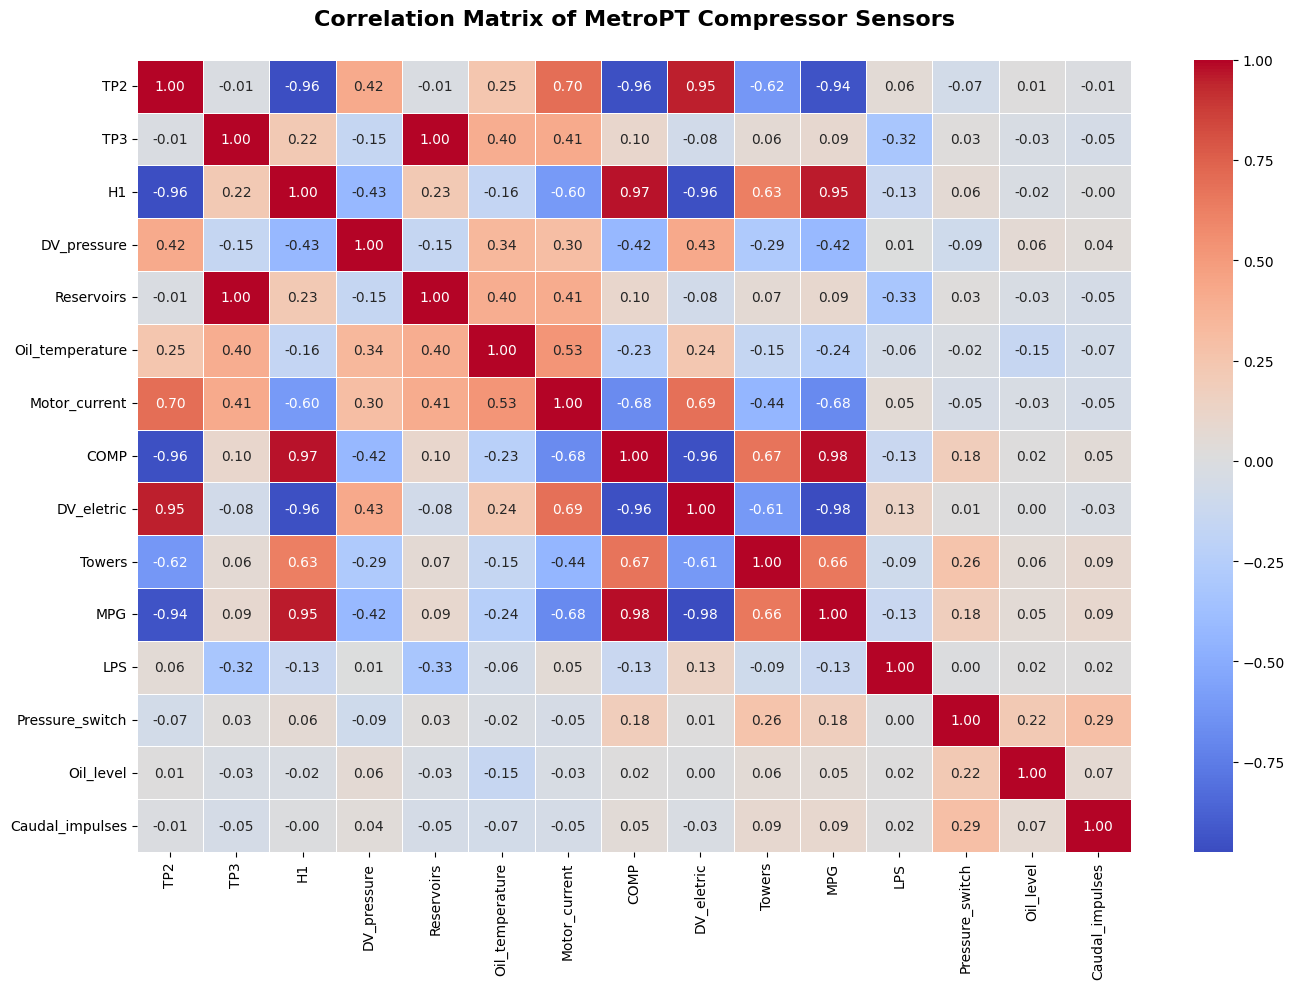

In [5]:
# ============================================================================
# 4. Multivariable Cross-Correlation Mapping
# ============================================================================
corr_matrix = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of MetroPT Compressor Sensors', fontsize=16, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

## 🏷️ Ground Truth Labeling & Chronological Dataset Partitioning

### Engineering Rationale
In industrial anomaly detection, we evaluate unsupervised models by comparing their predictions against known, documented failure windows. Based on the maintenance logs of the MetroPT3 compressor, a catastrophic anomaly event occurred on **April 18, 2020**.

To build a robust Semi-Supervised Outlier Detection framework, we construct our datasets as follows:
* **Training Dataset (`train_data`):** Extracted strictly from February 1 to March 31, 2020. This represents a completely stable, healthy operational profile (100% nominal behavior) where the model learns the "normal physical envelope" of the compressor.
* **Testing Dataset (`test_data`):** Extracted from April 1 to April 30, 2020. This window contains both normal running cycles and the target structural failure event, allowing us to evaluate the model's precision and recall under real-world degradation.

In [6]:
# ============================================================================
# 5. Anomaly Ground Truth Injection and Chronological Data Splitting
# ============================================================================
# Initialize the target ground truth vector with nominal states (0 = Healthy)
df['Is_Anomaly'] = 0

# Inject the documented functional failure window based on Metro maintenance logs
df.loc['2020-04-18 00:00:00':'2020-04-18 23:59:00', 'Is_Anomaly'] = 1

# A: Isolating the Purely Healthy Training Window
train_data = df.loc['2020-02-01':'2020-03-31']
print("=== Training Dataset Verification ===")
print(f"Total anomaly samples in Training Data (Must be 0): {(train_data['Is_Anomaly'] == 1).sum()}")
print(f"Total nominal samples in Training Data:              {(train_data['Is_Anomaly'] == 0).sum()}")

# B: Isolating the Evaluation/Testing Window
test_data = df.loc['2020-04-01':'2020-04-30']
print("\n=== Testing Dataset Verification ===")
print(f"Total Nominal samples (Class 0):  {(test_data['Is_Anomaly'] == 0).sum()}")
print(f"Total Anomaly samples (Class 1):  {(test_data['Is_Anomaly'] == 1).sum()}")

=== Training Dataset Verification ===
Total anomaly samples in Training Data (Must be 0): 0
Total nominal samples in Training Data:              445298

=== Testing Dataset Verification ===
Total Nominal samples (Class 0):  190077
Total Anomaly samples (Class 1):  8657


## ⚙️ Feature Isolation, Data Standardization, and Isolation Forest Training

### Engineering Rationale
* **Data Leakage Prevention:** The `StandardScaler` computes its mean and variance parameters strictly from the `X_train` dataset (the clean operational baseline). We then apply these identical parameters to scale the `X_test` matrix. This ensures that no statistical trends or anomaly thresholds from the failure window leak back into the training phase.
* **Contamination Calibration:** Because our training dataset is chronologically filtered to contain only nominal, healthy operations, we set the contamination factor to a highly conservative `0.01` (1%). This accounts for random electrical signal spikes or minor measurement noise without misclassifying baseline running states as functional degradation.
* **Prediction Re-mapping:** By default, Scikit-Learn’s Isolation Forest flags inliers as `1` and outliers as `-1`. To maintain alignment with standard industrial classification terminology and our ground-truth vector (0 for Healthy, 1 for Anomaly), we programmatically map the outputs using `np.where`.

In [7]:
# ============================================================================
# 6. Feature Selection, Standardization, and Baseline Model Execution
# ============================================================================
# Extract all raw sensor channels while strictly excluding the target label
features = [col for col in df.columns if col != 'Is_Anomaly']
X_train = train_data[features]
X_test = test_data[features]
y_test = test_data['Is_Anomaly']  # Ground truth answers reserved strictly for evaluation

# Fit scaler on training data and transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Isolation Forest
model = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
print("Training Isolation Forest on stable compressor operational profiles...")
model.fit(X_train_scaled)
print("Model training successfully completed! 🚀")

# Predict and map outputs (-1 -> 1 for Anomaly, 1 -> 0 for Normal)
test_predictions = model.predict(X_test_scaled)
y_pred = np.where(test_predictions == -1, 1, 0)

Training Isolation Forest on stable compressor operational profiles...
Model training successfully completed! 🚀


## 📊 Model Evaluation & Performance Analytics

### Engineering Rationale
In safety-critical applications like railway transit air compressors, evaluating a model based on raw accuracy is highly misleading due to severe class imbalance. Instead, we must prioritize two industrial Key Performance Indicators (KPIs):
* **Recall (Sensitivity):** Measures the model's capability to capture every single true anomaly slice. A low recall means a catastrophic failure went unnoticed (False Negative), risking train delays or braking system failure.
* **Precision:** Measures the reliability of the flagged anomalies. High precision guarantees that maintenance crews aren't dispatched for false alarms (False Positives), which optimizes operational expenditure (OPEX).

--- Anomaly Detection Model Classification Report (Isolation Forest) ---
                  precision    recall  f1-score   support

      Normal (0)       0.96      0.99      0.97    190077
Anomaly/Leak (1)       0.08      0.02      0.04      8657

        accuracy                           0.95    198734
       macro avg       0.52      0.51      0.50    198734
    weighted avg       0.92      0.95      0.93    198734



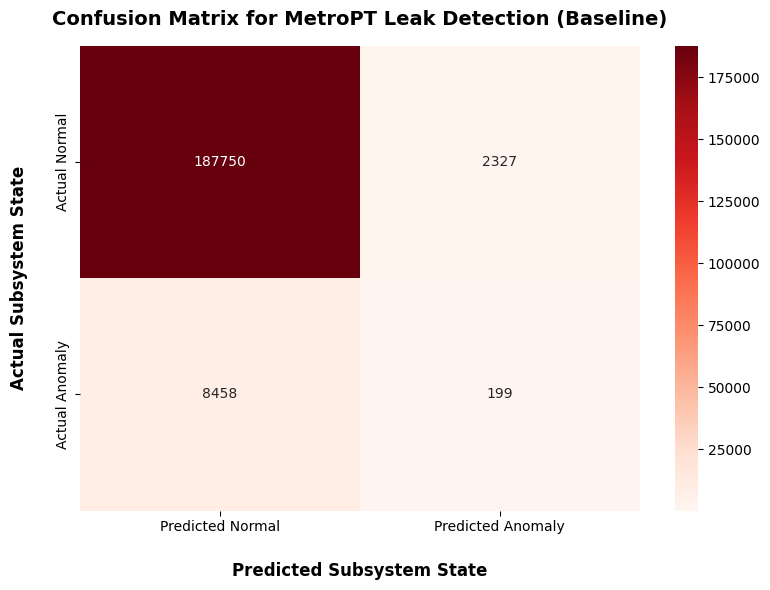

In [8]:
# ============================================================================
# 7. Comprehensive Baseline Model Reporting & Diagnostics
# ============================================================================
print("--- Anomaly Detection Model Classification Report (Isolation Forest) ---")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Anomaly/Leak (1)']))

# Visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix for MetroPT Leak Detection (Baseline)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Subsystem State', fontsize=12, labelpad=20, fontweight='bold')
plt.xlabel('Predicted Subsystem State', fontsize=12, labelpad=20, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Strategic Downsampling, Scaling, and One-Class SVM Execution

### Engineering Rationale
* **Computational Optimization & Geometry Preservation:** The One-Class SVM algorithm utilizes kernel-based computations (RBF), resulting in an $O(N^2)$ to $O(N^3)$ time complexity relative to the row count. Training on the raw, massive high-frequency dataset would cause severe CPU/RAM bottlenecks. By extracting a mathematically representative sample of 50,000 observations, we maintain the physical, thermodynamic, and pneumatic geometric boundaries of the compressor while shrinking training time from hours to seconds.
* **Hyperparameter Calibration ($\nu$):** The parameter `nu=0.01` acts as an upper bound on training error fractions and a lower bound on support vector fractions. Setting it to 1% perfectly mirrors the `contamination=0.01` threshold used in our Isolation Forest, ensuring an identical and fair benchmarking baseline.
* **Uncompromised Evaluation Pipeline:** While the training footprint is compressed via sampling, the evaluation matrix (`X_test`) remains completely intact (the full month of April). This guarantees that our benchmarking metrics evaluate both models against identical, uninterrupted operational degradation curves.

Training One-Class SVM on the optimized healthy telemetry sample...
Model training successfully completed in record time! 🚀
--- Anomaly Detection Model Classification Report (One-Class SVM) ---
                  precision    recall  f1-score   support

      Normal (0)       1.00      0.92      0.96    190077
Anomaly/Leak (1)       0.37      0.99      0.54      8657

        accuracy                           0.93    198734
       macro avg       0.69      0.96      0.75    198734
    weighted avg       0.97      0.93      0.94    198734



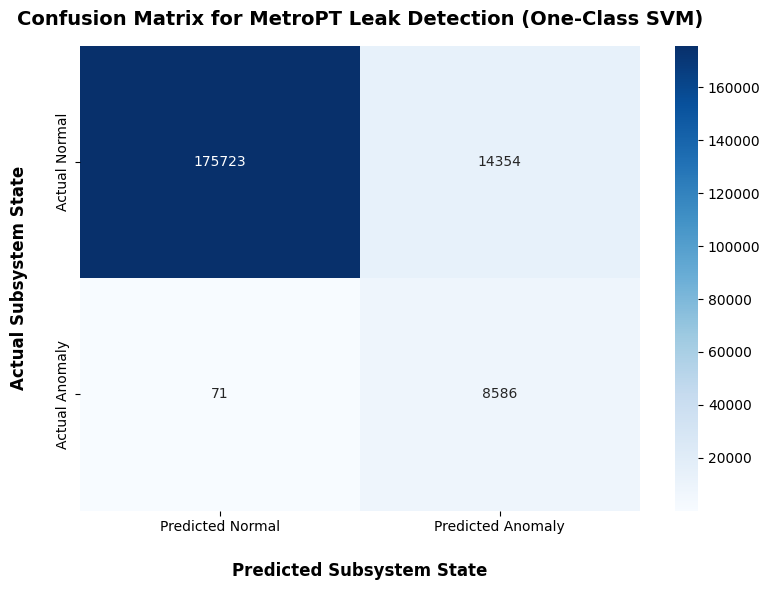

In [9]:
# ============================================================================
# 8. Optimized Downsampling, Scaling, and One-Class SVM Training Pipeline
# ============================================================================
# Extract an optimized random sample for SVM training efficiency
X_train_sampled = train_data[features].sample(n=50000, random_state=42)

# Build a dedicated scaling pipeline for the SVM pipeline
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_sampled)
X_test_svm_scaled = scaler_svm.transform(X_test)

# Initialize and fit One-Class SVM
oc_svm = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
print("Training One-Class SVM on the optimized healthy telemetry sample...")
oc_svm.fit(X_train_svm_scaled)
print("Model training successfully completed in record time! 🚀")

svm_preds = oc_svm.predict(X_test_svm_scaled)
y_pred_svm = np.where(svm_preds == -1, 1, 0)

print("--- Anomaly Detection Model Classification Report (One-Class SVM) ---")
print(classification_report(y_test, y_pred_svm, target_names=['Normal (0)', 'Anomaly/Leak (1)']))

# ============================================================================
# 9. Confusion Matrix Visualization for One-Class SVM
# ============================================================================
# Compute the confusion matrix using true labels and SVM predictions
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])

plt.title('Confusion Matrix for MetroPT Leak Detection (One-Class SVM)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Subsystem State', fontsize=12,  labelpad=20, fontweight='bold')
plt.xlabel('Predicted Subsystem State', fontsize=12,  labelpad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('Confusion_Matrix_for_MetroPT_Leak_Detection_(OneClassSVM).png', dpi=300)
plt.show()